# Figure: Welfare Analysis

This notebook generates welfare and profit figures from **Experiment 6** results.

**Inputs**: `../data/results_6/` (JSON files), `../data/instances/2020-08-27.yaml`

**Outputs**:
- `../figures/platform_profit.pdf` — Platform profit vs. ambiguity level ε, with observed averages overlaid
- `../figures/intermediary_welfare.pdf` — Intermediary welfare bounds (synthetic vs. observed)
- `../figures/farmer_welfare.pdf` — Farmer welfare bounds (synthetic vs. observed)
- `../figures/profit_by_contraint.pdf` — Platform profit by constraint type (vanilla, domination, structured pricing)

In [5]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from copy import deepcopy

from farmers_intermediaries import Instance
from road_graphs import RoadGraph
import pickle
import pandas as pd
import pricing
from pricing import Optimizer
from datetime import datetime, timedelta
import numpy as np


json_files = {}
directory = "../data/results_scaling_ints/0"

for filename in os.listdir(directory):
    if filename.endswith(".json"):
        filepath = os.path.join(directory, filename)
        with open(filepath, 'r') as file:
            json_files[filename] = json.load(file)

In [10]:
json_files['115.json'].keys()

dict_keys(['epsilon', 'cost', 'farmer_quantities', 'summary_vanilla', 'summary_structured', 'summary_domination', 'farmer_dirt_to_mill', 'farmer_paved_to_mill', 'instance_id', 'n_id'])

In [12]:
# We study the gaps
gap_dict = []
for name, result in json_files.items():
    gap_dict.append({
        "vanilla_profit": result["summary_vanilla"]["max_int_welf_sol"]["profit"]/14500.0,
        "structured_profit": result["summary_structured"]["max_int_welf_sol"]["profit"]/14500.0,
        "domination_profit": result["summary_domination"]["max_int_welf_sol"]["profit"]/14500.0,
        "suboptimal_profit": result["summary_vanilla"]["forced_lower_bound"]/14500.0,
        "time_vanilla": result["summary_vanilla"]["total_time"],
        "time_structured": result["summary_structured"]["total_time"],
        "time_domination": result["summary_domination"]["total_time"],
        "time_suboptimal": result["summary_vanilla"]["timestamps"][0],
        "avg_epsilon": np.mean(list(result["epsilon"].values())),
        'fruit_value': np.sum(list(result["farmer_quantities"].values())) * (2513.0 * 1000.0)/14500.0,
        'profit_percentage': result["summary_vanilla"]["max_int_welf_sol"]["profit"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        "instance": result["instance_id"],
        'max_welfare_farmers': result["summary_vanilla"]["min_int_welf_sol"]["farmer_welfare"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'min_welfare_farmers': result["summary_vanilla"]["max_int_welf_sol"]["farmer_welfare"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'max_welfare_intermediaries': result["summary_vanilla"]["max_int_welf_sol"]["intermediary_welfare"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'min_welfare_intermediaries': result["summary_vanilla"]["min_int_welf_sol"]["intermediary_welfare"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'matching_cost': result["summary_vanilla"]["max_int_welf_sol"]["matching_cost"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'optimal_cost': result["summary_vanilla"]["forced_cost"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
    })
df_gaps = pd.DataFrame(gap_dict)

# Bin epsilon into discrete intervals
df_gaps["diff_suboptimal"] = (df_gaps["vanilla_profit"] - df_gaps["suboptimal_profit"])/ df_gaps["fruit_value"]
df_gaps["diff_structured"] = (df_gaps["vanilla_profit"] - df_gaps["structured_profit"])/ df_gaps["fruit_value"]
df_gaps["diff_domination"] = (df_gaps["vanilla_profit"] - df_gaps["domination_profit"])/ df_gaps["fruit_value"]

df_gaps["suboptimal_speedup"] = df_gaps["time_vanilla"] / df_gaps["time_suboptimal"]
df_gaps["structured_speedup"] = df_gaps["time_vanilla"] / df_gaps["time_structured"]

df_gaps["vanilla_profit_by_fruit_value"] = df_gaps["vanilla_profit"] / df_gaps["fruit_value"]
df_gaps["structured_profit_by_fruit_value"] = df_gaps["structured_profit"] / df_gaps["fruit_value"]
df_gaps["domination_profit_by_fruit_value"] = df_gaps["domination_profit"] / df_gaps["fruit_value"]
df_gaps["suboptimal_profit_by_fruit_value"] = df_gaps["suboptimal_profit"] / df_gaps["fruit_value"]


# df_0 = df_gaps.query("avg_epsilon == 0.0")
# df_gaps = df_gaps.query("avg_epsilon >= 1.0")


In [14]:

actual_costs_platform = {0: 0.0775829869015126,
 1: 0.07768902868743288,
 2: 0.07792714074761442,
 3: 0.07779050019770295,
 4: 0.07780432119364723,
 5: 0.07780432119364725,
 6: 0.07758298690151258,
 7: 0.07758298690151257,
 8: 0.07758298690151258,
 9: 0.0775829869015126,
 }

actual_costs_improvement = {i: actual_costs_platform[i] - actual_costs_platform[0] for i in range(1, 10)}

actual_perc_platform = {0: 0.09959740695143612,
 1: 0.044517655245960054,
 2: 0.022845478696154217,
 3: 0.011845342163052535,
 4: 0.005042216382378989,
 5: 0.0009595428605521555,
 6: -0.002270061056467741,
 7: -0.004516052387438745,
 8: -0.005835568402234102,
 9: -0.007022154488203626}

actual_max_int = {0: 0.32758953661755996,
 1: 0.04175691614041955,
 2: 0.02060091126517644,
 3: 0.013039289559810586,
 4: 0.009350912870058112,
 5: 0.007924168304404811,
 6: 0.00772484422378011,
 7: 0.007443614889069343,
 8: 0.0063391957909994575,
 9: 0.005711990106601736}

actual_min_int = {0: 0.0,
 1: 0.01478574070810623,
 2: 0.007534357335050608,
 3: 0.007899933576455203,
 4: 0.005905858766726449,
 5: 0.006235383720283765,
 6: 0.0058198497457951585,
 7: 0.0073826381391337735,
 8: 0.006322061118747919,
 9: 0.00571137535532129}

actual_min_farmer = {0: 0.4952300812484759,
 1: 0.8360364116451723,
 2: 0.8786264810100395,
 3: 0.8973248797984186,
 4: 0.9078025612729003,
 5: 0.9133119793603803,
 6: 0.9169622416501595,
 7: 0.9194894623158415,
 8: 0.9219133974287067,
 9: 0.9237271891990739}

actual_max_farmer = {0: 0.8228196178660359,
 1: 0.8630075870774853,
 2: 0.8916930349401653,
 3: 0.9024642357817737,
 4: 0.911247615376232,
 5: 0.9150007639445015,
 6: 0.9188672361281446,
 7: 0.9195504390657769,
 8: 0.9219305321009583,
 9: 0.9237278039503545}



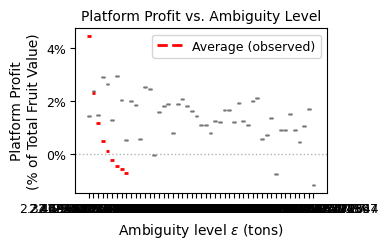

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

df_gaps = df_gaps.query("avg_epsilon >= 1.0")

plt.figure(figsize=(4, 2.6))

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Boxplot without outliers
ax = sns.boxplot(
    data=df_gaps, 
    x="avg_epsilon", 
    y="profit_percentage", 
    zorder=1, 
    showfliers=False,
    color="lightblue"
)

# Add horizontal reference line at 0% (lighter solid line)
plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

# Overlay observed value per category with a dashed line
for i, category in enumerate(list(range(1, 10))):
    obs = actual_perc_platform.get(category, None)
    if obs is not None:
        plt.plot(
            [i - 0.38, i + 0.42], 
            [obs, obs], 
            color="red", 
            linewidth=2, 
            linestyle="--",  # Dashed line for the average
            label="Average (observed)" if i == 0 else "", 
            zorder=10
        )

# Format y-axis as percentages
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Clean and informative labels
plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level")

# Only show one legend entry for the observed line
handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(handles[:1], labels[:1], loc="upper right")

plt.tight_layout()
plt.savefig("../figures/platform_profit.pdf", bbox_inches='tight')
plt.show()

KeyError: 'Average (observed)'

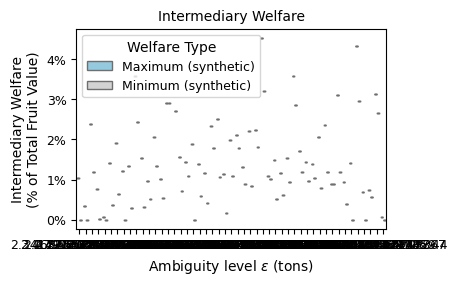

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually to ensure consistency
palette = {
    "Maximum (synthetic)": "skyblue", 
    "Minimum (synthetic)": "lightgray"
}

# Melt the dataframe
df_melted = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_welfare_intermediaries', 'min_welfare_intermediaries'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

# Improve category names for legend
df_melted['Welfare Type'] = df_melted['Welfare Type'].map({
    'max_welfare_intermediaries': 'Maximum (synthetic)', 
    'min_welfare_intermediaries': 'Minimum (synthetic)'
})

# Create boxplot
plt.figure(figsize=(4, 2.6))
ax = sns.boxplot(
    data=df_melted, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette=palette, 
    showfliers=False
)

# Overlay actual data lines with red dashed lines for averages
for i, category in enumerate(sorted(df_gaps["avg_epsilon"].unique())):
    obs_max = actual_max_int.get(category, None)
    obs_min = actual_min_int.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Labeling
plt.ylabel("Intermediary Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Intermediary Welfare")

# Legend cleanup
handles, labels = ax.get_legend_handles_labels()
# Deduplicate legend and ensure all three entries are present
unique = dict(zip(labels, handles))
plt.legend(
    [unique["Maximum (synthetic)"], unique["Minimum (synthetic)"], unique["Average (observed)"]],
    ["Maximum (synthetic)", "Minimum (synthetic)", "Average (observed)"],
    title="", loc="upper right"
)

plt.tight_layout()
plt.savefig("../figures/intermediary_welfare.pdf", bbox_inches='tight')
plt.show()

KeyError: 'Average (observed)'

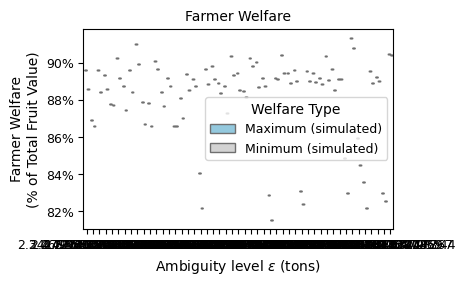

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually to ensure consistency
palette = {
    "Maximum (simulated)": "skyblue", 
    "Minimum (simulated)": "lightgray"
}

# Melt the dataframe
df_melted = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_welfare_farmers', 'min_welfare_farmers'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

# Improve category names for legend
df_melted['Welfare Type'] = df_melted['Welfare Type'].map({
    'max_welfare_farmers': 'Maximum (simulated)', 
    'min_welfare_farmers': 'Minimum (simulated)'
})

# Create boxplot
plt.figure(figsize=(4, 2.6))  # Adjusted figsize
ax = sns.boxplot(
    data=df_melted, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette=palette, 
    showfliers=False
)

# Overlay actual data lines with red dashed lines for averages
for i, category in enumerate(sorted(df_gaps["avg_epsilon"].unique())):
    obs_max = actual_max_farmer.get(category, None)
    obs_min = actual_min_farmer.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Labeling
plt.ylabel("Farmer Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Farmer Welfare")

# Legend cleanup
handles, labels = ax.get_legend_handles_labels()
# Deduplicate legend and ensure all three entries are present
unique = dict(zip(labels, handles))
plt.legend(
    [unique["Maximum (simulated)"], unique["Minimum (simulated)"], unique["Average (observed)"]],
    ["Maximum (simulated)", "Minimum (simulated)", "Average (observed)"],
    title="", loc="lower right"
)

plt.tight_layout()
plt.savefig("../figures/farmer_welfare.pdf", bbox_inches='tight')
plt.show()

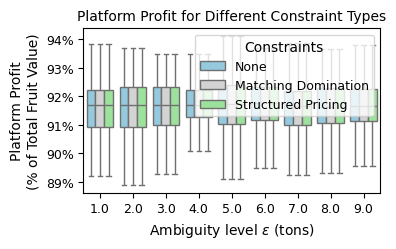

In [ ]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt

# Melt the dataframe for easier plotting
profit_data = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['vanilla_profit_by_fruit_value', 'domination_profit_by_fruit_value', 'structured_profit_by_fruit_value'], 
    var_name='Constraints', 
    value_name='Profit'
)

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually for consistency
palette = {
    "None": "skyblue", 
    "Matching Domination": "lightgray", 
    "Structured Pricing": "lightgreen"
}

# Improve category names for legend
profit_data['Constraints'] = profit_data['Constraints'].map({
    'vanilla_profit_by_fruit_value': 'None', 
    'domination_profit_by_fruit_value': 'Matching Domination', 
    'structured_profit_by_fruit_value': 'Structured Pricing'
})

# Create the boxplot
plt.figure(figsize=(4, 2.6))
ax = sns.boxplot(
    data=profit_data, 
    x="avg_epsilon", 
    y="Profit", 
    hue="Constraints", 
    palette=palette, 
    showfliers=False
)

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

# Labeling
plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit for Different Constraint Types")
# Format y-axis as percentages
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Constraints", loc="upper right")

plt.tight_layout()
plt.savefig("../figures/profit_by_contraint.pdf", bbox_inches='tight')
plt.show()